<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_5/LR_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.integrate import solve_ivp
from math import comb
import math
from typing import Optional

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

In [2]:
class ClosedSMO:
    """
    Математичне ядро замкнутої одноканальної СМО типу M/M/1//m.

    Реалізує:
    - Формування та розв'язання СЛАР рівнянь глобального балансу
      (аналог блоку Given...Find у Mathcad).
    - ОДР системи Колмогорова для аналізу перехідних процесів
      (аналог Odesolve у Mathcad).
    - Розрахунок показників ефективності.
    - Оптимізаційний перебір кількості джерел вимог.
    """

    def __init__(self, m: int, lam: float, mu: float) -> None:
        """
        Ініціалізує параметри системи.

        Parameters
        ----------
        m   : кількість джерел вимог (самоскидів)
        lam : інтенсивність звернень одного джерела [1/с]
        mu  : інтенсивність обслуговування [1/с]
        """
        self.m = m
        self.lam = lam
        self.mu = mu

    def solve_steady_state(self) -> np.ndarray:
        """
        Формує матрицю СЛАР рівнянь глобального балансу
        та розв'язує її методом numpy.linalg.solve.

        Returns
        -------
        P : масив стаціонарних ймовірностей P[0..m]
        """
        m, lam, mu = self.m, self.lam, self.mu
        size = m + 1
        A = np.zeros((size, size))
        B = np.zeros(size)

        A[0, 0] = -m * lam
        A[0, 1] = mu
        for k in range(1, m):
            A[k, k - 1] = (m - k + 1) * lam
            A[k, k]     = -((m - k) * lam + mu)
            A[k, k + 1] = mu
        A[m, m - 1] = lam
        A[m, m]     = -mu

        # Заміна останнього рядка умовою нормування: sum(P_k) = 1
        A[-1, :] = 1.0
        B[-1] = 1.0

        return np.linalg.solve(A, B)

    def _kolmogorov_rhs(self, t: float, P: np.ndarray) -> np.ndarray:
        """
        Права частина системи ОДР Колмогорова.
        Викликається інтегратором solve_ivp.
        """
        m, lam, mu = self.m, self.lam, self.mu
        dP = np.zeros(m + 1)
        dP[0] = mu * P[1] - m * lam * P[0]
        for k in range(1, m):
            dP[k] = ((m - k + 1) * lam * P[k - 1]
                     + mu * P[k + 1]
                     - ((m - k) * lam + mu) * P[k])
        dP[m] = lam * P[m - 1] - mu * P[m]
        return dP

    def solve_dynamics(
        self,
        P0_init: np.ndarray,
        t_end: float = 7200.0,
        n_points: int = 1000,
    ) -> tuple:
        """
        Інтегрує систему ОДР Колмогорова методом RK45.

        Parameters
        ----------
        P0_init : початковий розподіл ймовірностей (len = m+1)
        t_end   : кінцевий час інтеграції [с]
        n_points: кількість точок виводу

        Returns
        -------
        t : масив часових точок
        P : матриця P[k, t_idx]
        """
        t_eval = np.linspace(0.0, t_end, n_points)
        sol = solve_ivp(
            self._kolmogorov_rhs,
            (0.0, t_end),
            P0_init,
            t_eval=t_eval,
            method="RK45",
            rtol=1e-8,
            atol=1e-10,
        )
        return sol.t, sol.y

    @staticmethod
    def performance(m: int, P: np.ndarray, mu: float, ga: float) -> dict:
        """
        Розраховує ключові показники ефективності СМО.

        Parameters
        ----------
        m  : кількість джерел
        P  : масив стаціонарних ймовірностей
        mu : інтенсивність обслуговування [1/с]
        ga : ємність одного самоскиду [т]
        """
        eta      = 1.0 - P[0]
        L_s      = sum(k * P[k] for k in range(1, m + 1))
        L_q      = sum((k - 1) * P[k] for k in range(2, m + 1))
        Q_trucks = eta * mu * 3600.0
        Pf_t_h   = Q_trucks * ga
        return {
            "eta":        eta,
            "L_s":        L_s,
            "L_q":        L_q,
            "Q_trucks_h": Q_trucks,
            "Pf_t_h":     Pf_t_h,
        }

    def optimize_m(self, m_range: range, ga: float) -> pd.DataFrame:
        """
        Перебирає кількість самоскидів та розраховує показники
        ефективності для кожного значення m.

        Parameters
        ----------
        m_range : діапазон значень m для перебору
        ga      : ємність самоскиду [т]
        """
        rows = []
        for mi in m_range:
            smo_i = ClosedSMO(mi, self.lam, self.mu)
            Pi = smo_i.solve_steady_state()
            perf = self.performance(mi, Pi, self.mu, ga)
            rows.append({
                "m":           mi,
                "P0":          round(Pi[0], 6),
                "η":           round(perf["eta"], 6),
                "L_s":         round(perf["L_s"], 6),
                "L_q":         round(perf["L_q"], 6),
                "Pf (т/год)":  round(perf["Pf_t_h"], 4),
            })
        return pd.DataFrame(rows).set_index("m")

In [3]:
print("=" * 72)
print("  БЛОК 1: Параметри замкнутої СМО та розрахунок інтенсивностей")
print("=" * 72)

# Вихідні дані (Варіант 15, Таблиця 5.2)
m_trucks = 5        # кількість автосамоскидів
ga       = 1.0      # ємність кузова самоскиду, т
ge       = 6.0      # ємність ковша екскаватора, т
t_rts    = 17.0     # час робочого циклу екскаватора, с
t_turn   = 1200.0   # час обернення самоскиду, с  (20 хв * 60)

# Час завантаження одного самоскиду
# ceil(ga / ge) = ceil(1/6) = 1 — один ківш перевищує ємність кузова
n_scoops  = math.ceil(ga / ge)
t_service = n_scoops * t_rts      # час обслуговування, с

# Інтенсивності
lam = 1.0 / t_turn     # інтенсивність звернень одного самоскиду, 1/с
mu  = 1.0 / t_service  # інтенсивність обслуговування, 1/с
rho = lam / mu         # відносне навантаження від одного джерела

print(f"\nВхідні дані (Варіант 15):")
print(f"  Ємність самоскиду  (gₐ)    : {ga} т")
print(f"  Ємність ковша      (gₑ)    : {ge} т")
print(f"  Кількість самоскидів (m)   : {m_trucks}")
print(f"  Час робочого циклу  (tрц)  : {t_rts} с")
print(f"  Час обернення       (tоб)  : {t_turn} с  ({t_turn/60:.0f} хв)")
print(f"\nРозрахунок:")
print(f"  Кількість ківшів           : ceil({ga}/{ge}) = {n_scoops}")
print(f"  Час завантаження           : {n_scoops} × {t_rts} = {t_service} с")
print(f"  λ (інт. звернень)          : 1/{t_turn:.0f} = {lam:.8f} с⁻¹")
print(f"  μ (інт. обслуговування)    : 1/{t_service:.0f}  = {mu:.8f} с⁻¹")
print(f"  ρ = λ/μ                    : {rho:.8f}")

# Ініціалізація ядра
smo = ClosedSMO(m_trucks, lam, mu)

  БЛОК 1: Параметри замкнутої СМО та розрахунок інтенсивностей

Вхідні дані (Варіант 15):
  Ємність самоскиду  (gₐ)    : 1.0 т
  Ємність ковша      (gₑ)    : 6.0 т
  Кількість самоскидів (m)   : 5
  Час робочого циклу  (tрц)  : 17.0 с
  Час обернення       (tоб)  : 1200.0 с  (20 хв)

Розрахунок:
  Кількість ківшів           : ceil(1.0/6.0) = 1
  Час завантаження           : 1 × 17.0 = 17.0 с
  λ (інт. звернень)          : 1/1200 = 0.00083333 с⁻¹
  μ (інт. обслуговування)    : 1/17  = 0.05882353 с⁻¹
  ρ = λ/μ                    : 0.01416667


In [4]:
print("=" * 72)
print("  БЛОК 2: Стаціонарні ймовірності (СЛАР рівнянь Колмогорова)")
print("=" * 72)
print()
print("  Система рівнянь глобального балансу (аналог Given...Find у Mathcad):")
print("  Рядок 0 :  -m·λ·P₀ + μ·P₁ = 0")
print("  Рядок k :  (m-k+1)·λ·P_{k-1} - [(m-k)·λ + μ]·Pₖ + μ·P_{k+1} = 0")
print("  Рядок m :  λ·P_{m-1} - μ·Pₘ = 0")
print("  Нормування: ΣPₖ = 1  (замінює одне рівняння)")
print()

P_stat = smo.solve_steady_state()

# Верифікація нормування
assert np.isclose(P_stat.sum(), 1.0, atol=1e-10), "Порушення умови нормування!"

# Верифікація детального балансу
for k in range(1, m_trucks + 1):
    lhs = mu * P_stat[k]
    rhs = (m_trucks - k + 1) * lam * P_stat[k - 1]
    assert np.isclose(lhs, rhs, rtol=1e-6), f"Детальний баланс порушено для k={k}"

df_stat = pd.DataFrame({
    "Стан k":        [f"k = {k}" for k in range(m_trucks + 1)],
    "Опис":          [f"{k} самоскидів у системі, {m_trucks-k} вільних"
                      for k in range(m_trucks + 1)],
    "Pₖ":            [f"{p:.8f}" for p in P_stat],
    "Pₖ (%)":        [f"{p*100:.5f}" for p in P_stat],
})

print(df_stat.to_string(index=False))
print()
print(f"  Перевірка: ΣPₖ = {P_stat.sum():.12f}  ✓")
print(f"  Детальний баланс μ·Pₖ = (m-k+1)·λ·P_{{k-1}}  ✓ для всіх k = 1..{m_trucks}")

  БЛОК 2: Стаціонарні ймовірності (СЛАР рівнянь Колмогорова)

  Система рівнянь глобального балансу (аналог Given...Find у Mathcad):
  Рядок 0 :  -m·λ·P₀ + μ·P₁ = 0
  Рядок k :  (m-k+1)·λ·P_{k-1} - [(m-k)·λ + μ]·Pₖ + μ·P_{k+1} = 0
  Рядок m :  λ·P_{m-1} - μ·Pₘ = 0
  Нормування: ΣPₖ = 1  (замінює одне рівняння)

Стан k                              Опис         Pₖ   Pₖ (%)
 k = 0 0 самоскидів у системі, 5 вільних 0.93021290 93.02129
 k = 1 1 самоскидів у системі, 4 вільних 0.06589008  6.58901
 k = 2 2 самоскидів у системі, 3 вільних 0.00373377  0.37338
 k = 3 3 самоскидів у системі, 2 вільних 0.00015869  0.01587
 k = 4 4 самоскидів у системі, 1 вільних 0.00000450  0.00045
 k = 5 5 самоскидів у системі, 0 вільних 0.00000006  0.00001

  Перевірка: ΣPₖ = 1.000000000000  ✓
  Детальний баланс μ·Pₖ = (m-k+1)·λ·P_{k-1}  ✓ для всіх k = 1..5


In [5]:
print("=" * 72)
print("  БЛОК 3: Показники ефективності комплексу (m = 5)")
print("=" * 72)

perf = ClosedSMO.performance(m_trucks, P_stat, mu, ga)

print(f"\n  P₀  (ймовірність простою екскаватора)    : {P_stat[0]:.6f}  ({P_stat[0]*100:.4f} %)")
print(f"  η   (коефіцієнт використання)             : {perf['eta']:.6f}  ({perf['eta']*100:.4f} %)")
print(f"  Lₛ  (серед. к-ть самоскидів у системі)   : {perf['L_s']:.6f}")
print(f"  L_q (серед. довжина черги)                : {perf['L_q']:.6f}")
print(f"  Q   (пропускна здатність)                 : {perf['Q_trucks_h']:.4f} рейсів/год")
print(f"  Pf  (продуктивність комплексу)            : {perf['Pf_t_h']:.4f} т/год")

print()
if perf['eta'] < 0.5:
    print(f"  ВИСНОВОК: Екскаватор завантажений лише на {perf['eta']*100:.1f}%.")
    print(f"  При m = {m_trucks} самоскидах система суттєво розвантажена.")
    print(f"  Рекомендовано збільшити кількість самоскидів (див. Блок 4).")
elif perf['L_q'] > 2.0:
    print("  ВИСНОВОК: Черга критична. Доцільно додати канал обслуговування.")
else:
    print("  ВИСНОВОК: Система збалансована.")

print()
print("  Зведена таблиця (формат методичних вказівок):")
df_summary = pd.DataFrame({
    "n":          list(range(m_trucks + 1)),
    "Pₙ":         [round(p, 6) for p in P_stat],
    "n·Pₙ":       [round(k * P_stat[k], 6) for k in range(m_trucks + 1)],
    "(n-1)·Pₙ":   [round(max(0, k-1) * P_stat[k], 6) for k in range(m_trucks + 1)],
})
print(df_summary.to_string(index=False))
print(f"\n  Σn·Pₙ    = {sum(k*P_stat[k] for k in range(m_trucks+1)):.6f}  → Lₛ")
print(f"  Σ(n-1)·Pₙ = {sum(max(0,k-1)*P_stat[k] for k in range(m_trucks+1)):.6f}  → L_q")

  БЛОК 3: Показники ефективності комплексу (m = 5)

  P₀  (ймовірність простою екскаватора)    : 0.930213  (93.0213 %)
  η   (коефіцієнт використання)             : 0.069787  (6.9787 %)
  Lₛ  (серед. к-ть самоскидів у системі)   : 0.073852
  L_q (серед. довжина черги)                : 0.004065
  Q   (пропускна здатність)                 : 14.7784 рейсів/год
  Pf  (продуктивність комплексу)            : 14.7784 т/год

  ВИСНОВОК: Екскаватор завантажений лише на 7.0%.
  При m = 5 самоскидах система суттєво розвантажена.
  Рекомендовано збільшити кількість самоскидів (див. Блок 4).

  Зведена таблиця (формат методичних вказівок):
 n       Pₙ     n·Pₙ  (n-1)·Pₙ
 0 0.930213 0.000000  0.000000
 1 0.065890 0.065890  0.000000
 2 0.003734 0.007468  0.003734
 3 0.000159 0.000476  0.000317
 4 0.000004 0.000018  0.000013
 5 0.000000 0.000000  0.000000

  Σn·Pₙ    = 0.073852  → Lₛ
  Σ(n-1)·Pₙ = 0.004065  → L_q


  БЛОК 4: Оптимізація кількості самоскидів (перебір m = 1..15)

          P0         η       L_s       L_q  Pf (т/год)
m                                                     
1   0.986031  0.013969  0.013969  0.000000      2.9581
2   0.972068  0.027932  0.028322  0.000390      5.9150
3   0.958110  0.041890  0.043076  0.001186      8.8708
4   0.944158  0.055842  0.058247  0.002405     11.8253
5   0.930213  0.069787  0.073852  0.004065     14.7784
6   0.916274  0.083726  0.089910  0.006183     17.7303
7   0.902341  0.097659  0.106439  0.008780     20.6807
8   0.888416  0.111584  0.123461  0.011877     23.6296
9   0.874497  0.125503  0.140997  0.015495     26.5770
10  0.860587  0.139413  0.159070  0.019657     29.5228
11  0.846684  0.153316  0.177704  0.024388     32.4669
12  0.832790  0.167210  0.196924  0.029714     35.4092
13  0.818904  0.181096  0.216758  0.035662     38.3497
14  0.805027  0.194973  0.237234  0.042262     41.2883
15  0.791160  0.208840  0.258383  0.049544     44.2248



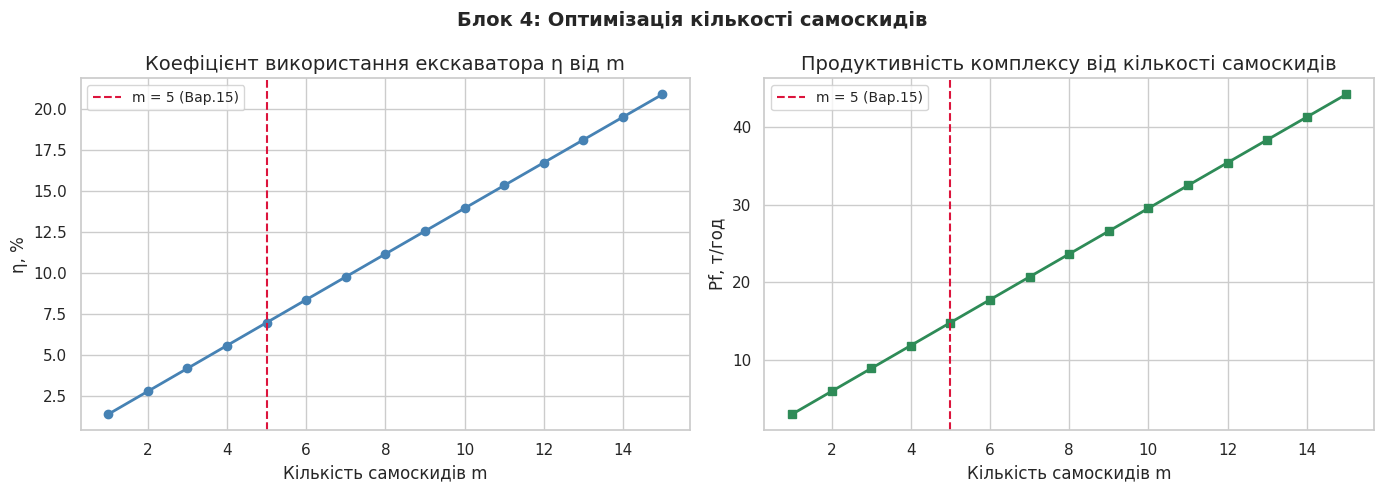

In [6]:
print("=" * 72)
print("  БЛОК 4: Оптимізація кількості самоскидів (перебір m = 1..15)")
print("=" * 72)
print()

df_opt = smo.optimize_m(range(1, 16), ga)
print(df_opt.to_string())

# Знаходимо m при якому приріст продуктивності < 2%
pf_vals = df_opt["Pf (т/год)"].values
m_vals  = list(range(1, 16))
m_opt   = m_vals[-1]
for i in range(1, len(pf_vals)):
    if (pf_vals[i] - pf_vals[i-1]) / pf_vals[i-1] < 0.02:
        m_opt = m_vals[i - 1]
        break

print()
print(f"  Варіант 15 (m = {m_trucks}): Pf = {df_opt.loc[m_trucks, 'Pf (т/год)']:.4f} т/год")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
m_arr  = np.array(m_vals)
eta_arr = df_opt["η"].values
pf_arr  = df_opt["Pf (т/год)"].values

axes[0].plot(m_arr, eta_arr * 100, "o-", color="steelblue", linewidth=2)
axes[0].axvline(m_trucks, color="crimson", linestyle="--", label=f"m = {m_trucks} (Вар.15)")
axes[0].set_title("Коефіцієнт використання екскаватора η від m")
axes[0].set_xlabel("Кількість самоскидів m")
axes[0].set_ylabel("η, %")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(m_arr, pf_arr, "s-", color="seagreen", linewidth=2)
axes[1].axvline(m_trucks, color="crimson", linestyle="--", label=f"m = {m_trucks} (Вар.15)")
axes[1].set_title("Продуктивність комплексу від кількості самоскидів")
axes[1].set_xlabel("Кількість самоскидів m")
axes[1].set_ylabel("Pf, т/год")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Блок 4: Оптимізація кількості самоскидів", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
print("=" * 72)
print("  БЛОК 5: Динаміка перехідних процесів (ОДР Колмогорова)")
print("=" * 72)
print()
print("  dP₀/dt = μ·P₁ - m·λ·P₀")
print("  dPₖ/dt = (m-k+1)·λ·P_{k-1} - [(m-k)·λ + μ]·Pₖ + μ·P_{k+1},  1 ≤ k < m")
print("  dPₘ/dt = λ·P_{m-1} - μ·Pₘ")
print()
print("  Початкові умови: P₁(0) = 1, всі інші Pₖ(0) = 0.")

# Початковий стан: один самоскид розпочинає завантаження
P0_init = np.zeros(m_trucks + 1)
P0_init[1] = 1.0

# Інтеграція на 2 год = 7200 с
t_dyn, P_dyn = smo.solve_dynamics(P0_init, t_end=7200.0, n_points=1000)
t_min = t_dyn / 60.0   # переводимо в хвилини

print()
print("  Порівняння фінальних значень ОДР та СЛАР (t = 7200 с = 2 год):")
print(f"  {'Стан':<8} {'ОДР P(t=2год)':<20} {'СЛАР (стаціонар)':<20} {'Δ'}")
print("  " + "-" * 60)
for k in range(m_trucks + 1):
    diff = abs(P_dyn[k, -1] - P_stat[k])
    print(f"  P{k:<7} {P_dyn[k,-1]:<20.10f} {P_stat[k]:<20.10f} {diff:.2e}")

print()
print(f"  ΣPₖ(t=7200) = {P_dyn[:,-1].sum():.12f}  ✓")

  БЛОК 5: Динаміка перехідних процесів (ОДР Колмогорова)

  dP₀/dt = μ·P₁ - m·λ·P₀
  dPₖ/dt = (m-k+1)·λ·P_{k-1} - [(m-k)·λ + μ]·Pₖ + μ·P_{k+1},  1 ≤ k < m
  dPₘ/dt = λ·P_{m-1} - μ·Pₘ

  Початкові умови: P₁(0) = 1, всі інші Pₖ(0) = 0.

  Порівняння фінальних значень ОДР та СЛАР (t = 7200 с = 2 год):
  Стан     ОДР P(t=2год)        СЛАР (стаціонар)     Δ
  ------------------------------------------------------------
  P0       0.9302129030         0.9302129031         1.20e-10
  P1       0.0658900808         0.0658900806         1.59e-10
  P2       0.0037337712         0.0037337712         4.49e-11
  P3       0.0001586853         0.0001586853         6.76e-12
  P4       0.0000044961         0.0000044961         5.58e-13
  P5       0.0000000637         0.0000000637         2.01e-14

  ΣPₖ(t=7200) = 1.000000000000  ✓


  БЛОК 6: Графічна інтерпретація результатів


/tmp/ipykernel_12272/1422230846.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


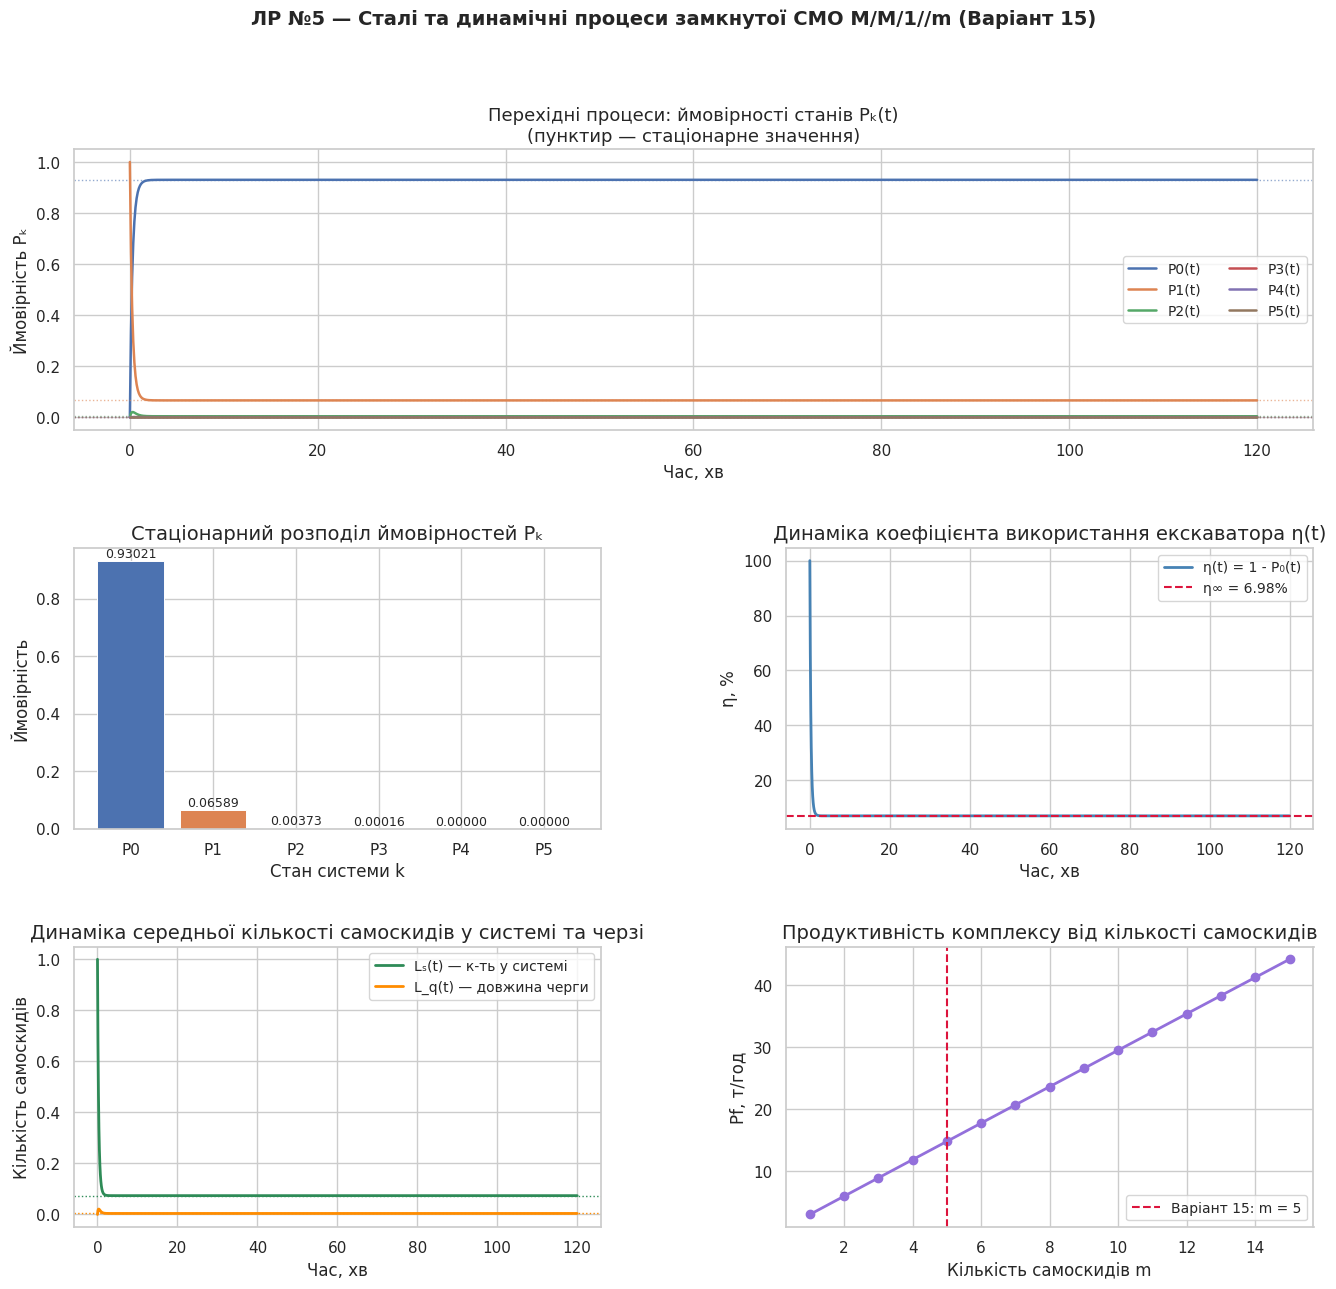

In [8]:
print("=" * 72)
print("  БЛОК 6: Графічна інтерпретація результатів")
print("=" * 72)

palette = sns.color_palette("deep", m_trucks + 1)

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.35)

# (A) Динаміка P_k(t)
ax_a = fig.add_subplot(gs[0, :])
for k in range(m_trucks + 1):
    ax_a.plot(t_min, P_dyn[k], color=palette[k], linewidth=1.8, label=f"P{k}(t)")
    ax_a.axhline(P_stat[k], color=palette[k], linestyle=":", linewidth=1.0, alpha=0.6)
ax_a.set_title("Перехідні процеси: ймовірності станів Pₖ(t)\n"
               "(пунктир — стаціонарне значення)", fontsize=13)
ax_a.set_xlabel("Час, хв")
ax_a.set_ylabel("Ймовірність Pₖ")
ax_a.legend(loc="right", ncol=2)
ax_a.grid(True)

# (B) Гістограма стаціонарних ймовірностей
ax_b = fig.add_subplot(gs[1, 0])
x_labels = [f"P{k}" for k in range(m_trucks + 1)]
bars = ax_b.bar(x_labels, P_stat, color=palette, edgecolor="white", linewidth=0.7)
for bar, val in zip(bars, P_stat):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
              f"{val:.5f}", ha="center", va="bottom", fontsize=9)
ax_b.set_title("Стаціонарний розподіл ймовірностей Pₖ")
ax_b.set_xlabel("Стан системи k")
ax_b.set_ylabel("Ймовірність")
ax_b.grid(True, axis="y")

# (C) Динаміка коефіцієнта завантаження η(t)
ax_c = fig.add_subplot(gs[1, 1])
ax_c.plot(t_min, (1 - P_dyn[0]) * 100, color="steelblue", linewidth=2, label="η(t) = 1 - P₀(t)")
ax_c.axhline((1 - P_stat[0]) * 100, color="crimson", linestyle="--", linewidth=1.5,
             label=f"η∞ = {(1 - P_stat[0])*100:.2f}%")
ax_c.set_title("Динаміка коефіцієнта використання екскаватора η(t)")
ax_c.set_xlabel("Час, хв")
ax_c.set_ylabel("η, %")
ax_c.legend()
ax_c.grid(True)

# (D) Динаміка Ls(t) та Lq(t)
ax_d = fig.add_subplot(gs[2, 0])
Ls_t = np.array([sum(k * P_dyn[k, i] for k in range(1, m_trucks + 1))
                 for i in range(len(t_min))])
Lq_t = np.array([sum((k - 1) * P_dyn[k, i] for k in range(2, m_trucks + 1))
                 for i in range(len(t_min))])
ax_d.plot(t_min, Ls_t, color="seagreen",   linewidth=2, label="Lₛ(t) — к-ть у системі")
ax_d.plot(t_min, Lq_t, color="darkorange", linewidth=2, label="L_q(t) — довжина черги")
ax_d.axhline(perf["L_s"], color="seagreen",   linestyle=":", linewidth=1)
ax_d.axhline(perf["L_q"], color="darkorange", linestyle=":", linewidth=1)
ax_d.set_title("Динаміка середньої кількості самоскидів у системі та черзі")
ax_d.set_xlabel("Час, хв")
ax_d.set_ylabel("Кількість самоскидів")
ax_d.legend()
ax_d.grid(True)

# (E) Pf(m) — продуктивність від кількості самоскидів
ax_e = fig.add_subplot(gs[2, 1])
m_arr_plot  = list(range(1, 16))
pf_arr_plot = [df_opt.loc[mi, "Pf (т/год)"] for mi in m_arr_plot]
ax_e.plot(m_arr_plot, pf_arr_plot, "o-", color="mediumpurple", linewidth=2)
ax_e.axvline(m_trucks, color="crimson", linestyle="--", linewidth=1.5,
             label=f"Варіант 15: m = {m_trucks}")
ax_e.set_title("Продуктивність комплексу від кількості самоскидів")
ax_e.set_xlabel("Кількість самоскидів m")
ax_e.set_ylabel("Pf, т/год")
ax_e.legend()
ax_e.grid(True)

plt.suptitle(
    "ЛР №5 — Сталі та динамічні процеси замкнутої СМО M/M/1//m (Варіант 15)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()